### CNN baseline

In [1]:
import time

from tensorflow import keras
import tensorflow as tf

from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from keras.layers import GlobalAveragePooling2D

#### MNIST dataset 

In [2]:
# load dataset
(x_train, y_train),(x_test, y_test) = keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0  
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 1/6, random_state=42)

In [3]:
def create_shifted_dataset(images, canvas_size=64, random_shift=True):
    dataset = np.zeros((len(images), canvas_size, canvas_size))
    coords = []
    for i, img in enumerate(images):
        if random_shift:
            h_off = np.random.randint(0, canvas_size - 28)
            v_off = np.random.randint(0, canvas_size - 28)
        else:
            h_off, v_off = (canvas_size-28)//2, (canvas_size-28)//2 # Centered

        dataset[i, v_off:v_off+28, h_off:h_off+28] = img
        coords.append([v_off / canvas_size, h_off / canvas_size]) # Normalized coords
    return dataset, np.array(coords)

In [4]:
X_train_canvas, _ = create_shifted_dataset(x_train[...,0], random_shift=False) # to train on original dataset (ie, just add padding around digit)
x_val_canvas, _ = create_shifted_dataset(x_val[...,0], random_shift=False) # same for validation

In [5]:
x_test_canvas, _ =  create_shifted_dataset(x_test[...,0], random_shift=False) # and for testing

In [6]:
def make_conv_model():
  model = Sequential()

  model.add(Conv2D(filters = 10, kernel_size = (5,5), padding = 'Same', 
                  activation ='relu', input_shape = (64,64,1)))
  model.add(Conv2D(filters = 10, kernel_size = (5,5), padding = 'Same', 
                  activation ='relu'))
  model.add(MaxPool2D(pool_size=(2,2))) # 64 -> 32
  model.add(MaxPool2D(pool_size=(2,2))) # 32 -> 16

  model.add(GlobalAveragePooling2D())
  #model.add(Flatten()) # discarded as it would not allow for translational equivariance
  #model.add(Dense(64, activation = "relu"))
  #model.add(Dropout(0.2))
    
  model.add(Dense(10, activation = "softmax"))
  optimizer = keras.optimizers.Adam()

  model.compile(optimizer=optimizer,
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']) 
  return model

In [7]:
# build model
simple_conv_model = make_conv_model()

C:\Users\Libero\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
simple_conv_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 10)          │             260 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 10)          │           2,510 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 10)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 10)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 10)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │             110 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,880 (11.25 KB)

 Trainable params: 2,880 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# train
epochs = 10 # can add more to push it?
batch_size = 86

i=time.time()
simple_conv_history = simple_conv_model.fit(X_train_canvas, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_val_canvas, y_val), verbose=1,
                                            callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)])
f=time.time()
print(f-i)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 85s 142ms/step - accuracy: 0.2440 - loss: 2.0639 - val_accuracy: 0.3454 - val_loss: 1.8483
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 83s 142ms/step - accuracy: 0.4203 - loss: 1.6724 - val_accuracy: 0.4939 - val_loss: 1.5249
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 82s 142ms/step - accuracy: 0.5288 - loss: 1.4016 - val_accuracy: 0.5550 - val_loss: 1.3055
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 86s 148ms/step - accuracy: 0.6071 - loss: 1.2121 - val_accuracy: 0.6088 - val_loss: 1.1507
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 81s 139ms/step - accuracy: 0.6686 - loss: 1.0610 - val_accuracy: 0.6865 - val_loss: 1.0091
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 81s 138ms/step - accuracy: 0.7127 - loss: 0.9434 - val_accuracy: 0.7328 - val_loss: 0.9045
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 77s 132ms/step - accuracy: 0.7476 - loss: 0.8483 - val_accuracy: 0.7563 - val_loss: 0.8271
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 79s 136ms/step - accuracy: 0.7707 - loss: 0

In [14]:
# test
simple_conv_test_loss, simple_conv_test_acc = simple_conv_model.evaluate(x_test_canvas, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8029 - loss: 0.6262


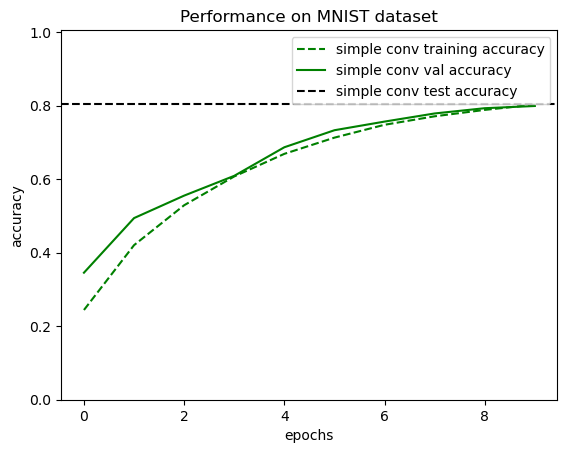

In [19]:
# plot
plt.plot(simple_conv_history.history["accuracy"], "g--",label="simple conv training accuracy")
plt.plot(simple_conv_history.history["val_accuracy"], "g-",label="simple conv val accuracy")
plt.axhline(simple_conv_test_acc,color="k", linestyle="--", label="simple conv test accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.title("Performance on MNIST dataset")
plt.ylim(0., 1.005)
plt.legend()

#### Shifted dataset

We expect similar results, as CNNs are known to have translation-equivariance property. (Although this has been questioned in recent works).

In [20]:
X_test_shift, _ = create_shifted_dataset(x_test[...,0], random_shift=True)  # test on shifted digits

# test
simple_conv_test_loss_shift, simple_conv_test_acc_shift = simple_conv_model.evaluate(X_test_shift, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7523 - loss: 0.7423


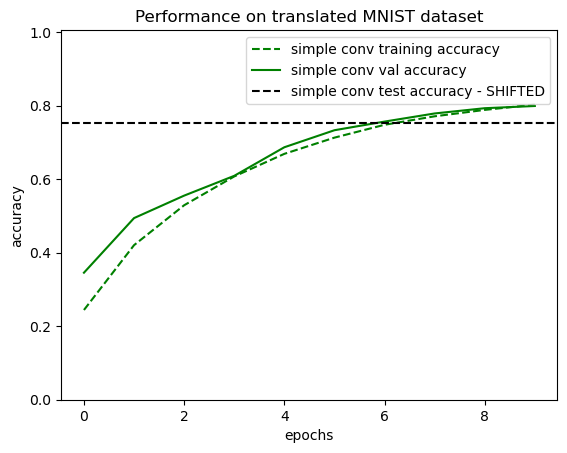

In [24]:
# plot
plt.plot(simple_conv_history.history["accuracy"], "g--",label="simple conv training accuracy")
plt.plot(simple_conv_history.history["val_accuracy"], "g-",label="simple conv val accuracy")
plt.axhline(simple_conv_test_acc_shift,color="k", linestyle="--", label="simple conv test accuracy - SHIFTED")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.title("Performance on translated MNIST dataset")
plt.ylim(0., 1.005)
plt.legend()